# Notebook for parameter searching of parameter space for MCMC Model 
Created by MTH on 04/29/2025

This notebook is to explore sampling of the Sobol space to generate different runs of the MCMC model. 

### Updating on 7/14/2025 
Given more recent results, I want to carry out additional approaches following this sampling scheme, but more precisely setup, and also for twitches. 

[Jump to section here](#updates-with-new-selected-sampling-sapce)

Rough approach for the sampling approach: 
1. Create a sampling of the different Sobol space, with number of samples. This array will be n_samples, n_params. Therefore, the rows, the different columns will be rescaled based on the bound of the param. 
2. Read in the default parameter list into the dictionary structure as carried out previously. 
3. Honestly, probably best to create the full df, with the default parameters, then replace the columns as they are rescaled. 
4. The pandas write to csv should output the variables in the correct structure. 


In [8]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc 

import yaml 
import os 

In [9]:
file_path = "/crucial/modified_MCMC/dATP_multiscale_modeling/resultsOrg/optiziation_dir/example_yaml_in.yml"
try:
    with open(file_path, 'r') as file:
        config = yaml.safe_load(file)
except FileNotFoundError:
    raise FileNotFoundError(f"Configuration file not found: {file_path}")
except yaml.YAMLError as e:
    raise yaml.YAMLError(f"Error parsing YAML file: {e}")

In [10]:
n_params = len(config['search_space'])
sampler = qmc.Sobol(d=n_params, seed = 43)
n_points = 8000

print("Requested number of points: ", n_points)
m = int(np.log2(n_points)//1+1)
print("Actual numer of points: ", 2**m)
n_points = 2**m
sample = sampler.random_base2(m=m)

sample.shape

Requested number of points:  8000
Actual numer of points:  8192


(8192, 10)

In [11]:
config['search_space']

{'k_force_baseline': [0.2, 0.001, 50],
 'k_plus_SR_baseline': [16.0, 1, 20.0],
 'k2_plus_baseline': [0.0015, 0.0001, 5],
 'k3_plus_baseline': [0.05, 0.0001, 5],
 'k4_plus_ref_baseline': [0.135, 0.0001, 5],
 'gamma_M': [21.0, 1, 60.0],
 'mu_M': [2.0, 1.0, 60],
 'alpha': [0.28, 0.0, 1],
 'beta': [0.35, 0, 1],
 'eta': [0.68, 0, 1]}

In [12]:
def read_default_params(filename):
    '''
    This function will read in the default parameters that are going to be used in the simulations. 
    The user can specify the default parameters in a CSV file that is read in by this function. 
    If the user does not specify a default parameter, then the default value will be used. 

    '''
    parameters = pd.read_csv(filename, na_filter=True, comment='#')
    parameters.dropna(inplace=True)
    # Convert the dataframe (series) to a dictionary
    parameter_dict = parameters.iloc[0].to_dict()

    return parameter_dict

default_params = read_default_params("/crucial/modified_MCMC/dATP_multiscale_modeling/parameters/parameter_input.csv")

In [13]:
def write_csv_file(input_dict, filename = "MCMC_temp_input.csv", append = False):
    '''
    This function will write a CSV file that has the input parameters that are going to be optimized. 
    The rest of the values will be the same as the default values. 

    '''
    if append == False:
        f = open(filename, "w")
        count = 0
        new_line = ""
        for key in input_dict.keys():
            new_line += str(key)
            new_line += ","
        new_line = new_line[:-1] + "\n"
        f.write(new_line)
        new_line = ""
        for key in input_dict.keys():
            new_line += str(input_dict[key])
            new_line += ","
        new_line = new_line[:-1] + "\n"
        f.write(new_line)
        f.close()
        print("Wrote temporary input file to: ", filename)

    elif append == True:
        try:
            f = open(filename, "r")
            f.close()
            write_header = False
        except:
            print("File does not exist, creating new file. ")
            write_header = True
        f = open(filename, "a")
        if write_header == True:
            new_line = ""
            for key in input_dict.keys():
                new_line += str(key)
                new_line += ","
            new_line = new_line[:-1] + "\n"
            f.write(new_line)
        new_line = ""
        for key in input_dict.keys():
            new_line += str(input_dict[key])
            new_line += ","
        new_line = new_line[:-1] + "\n"
        f.write(new_line)
        f.close()
        print("Appended input file to: ", filename)
    return filename

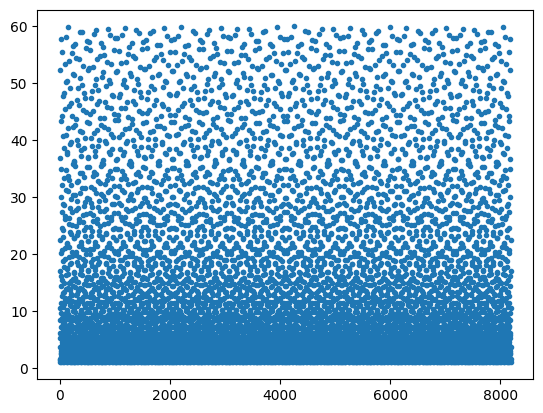

In [14]:
def transform_sample_vector(input_random_vector, low, high):
    """
    Transform a random vector from the unit hypercube to the specified range.
    
    Parameters:
    - input_random_vector: The random vector in the unit hypercube.
    - lower_bound: The lower bound of the desired range.
    - upper_bound: The upper bound of the desired range.
    
    Returns:
    - Transformed random vector in the specified range.
    """
    if low == 0 and high == 1:
        return input_random_vector
    return 10 ** (np.log10(low) + input_random_vector * (np.log10(high) - np.log10(low)))

new_vector = transform_sample_vector(sample[:, 0], config['search_space']['mu_M'][1], config['search_space']['mu_M'][2])

plt.plot(new_vector, '.')

In [15]:
# Create empty df that will get written to the csv 
df = pd.DataFrame()
for key in default_params.keys():
    df[key] = [default_params[key]]*n_points

In [16]:
for i, key in enumerate(config['search_space']):
    value, lower_bound, upper_bound = config['search_space'][key]
    df[key] = transform_sample_vector(sample[:, i], lower_bound, upper_bound)

In [17]:
filename = f"Generated_log_sobol_input_{n_points}.csv"

if os.path.exists(filename):
    print(f"File {filename} already exists. ")
else: 
    print("File does not exist, writing file: ", filename )
    # df.to_csv(filename, index = False)


File Generated_log_sobol_input_8192.csv already exists. 


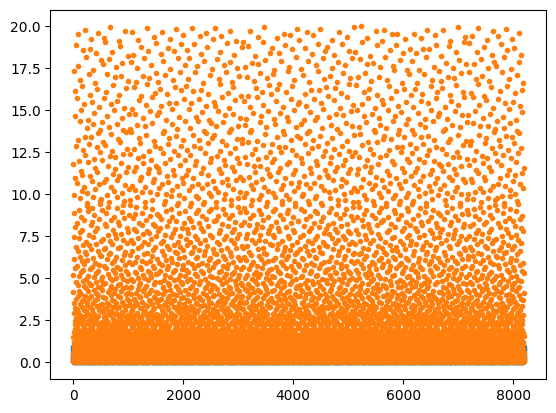

In [18]:
x = sample[:,i]
plt.plot(x,'.')



low = 0.05
high = 20
log_values = 10 ** (np.log10(low) + x * (np.log10(high) - np.log10(low)))

plt.plot(log_values, '.')

# Updates with new selected sampling sapce 
Updated on 8/14/2025

Note that we don't want to explore the same exact parameter space that was used previously. However, some of the techniques and scaling approaches were useful, so we can copy a lot of the framework. 

In [30]:
def generate_samples(n_samples, n_params):
    
    sampler = qmc.Sobol(d=n_params, seed = 43)

    print("Requested number of points: ", n_samples)
    m = int(np.log2(n_samples)//1+1)
    print("Actual numer of points: ", 2**m)
    n_samples = 2**m
    sample = sampler.random_base2(m=m)

    return sample



In [39]:
param_name_list = ["protocol","k_force_baseline","k_force_drug","k_plus_SR_baseline","k_plus_SR_drug","k_minus_SR","k_xb","k1_plus_ref_baseline","k1_plus_ref_drug","k2_plus_baseline","k2_plus_drug","k3_plus_baseline","k3_plus_drug","k4_plus_ref_baseline","k4_plus_ref_drug","kB_plus_ref","kB_minus_ref","kCa_plus_ref","kCa_minus_ref","percent_drug","lambda","gamma_B","gamma_M","mu_B","mu_M","q","r","x_preR","x_xb","conc_ADP","conc_ATP","conc_Pi","delta_G_ATP","alpha","beta","eta","g_Cb","g_Ca"]
param_value_list = [1,0.2,779,16,16,15,5,0.0025,0.00478,0.0015,0.0015,0.05,0.08,0.135,0.23,13,0.1,0.09,0.57,0.0,0,45,21,21,2,1,1,0,0.075,30e-6,5e-3,3e-3,-13,0.28,0.35,0.68,0,1]

starting_parm_values = pd.DataFrame([param_value_list], columns = param_name_list)

starting_parm_values.iloc[0]

protocol                  1.00000
k_force_baseline          0.20000
k_force_drug            779.00000
k_plus_SR_baseline       16.00000
k_plus_SR_drug           16.00000
k_minus_SR               15.00000
k_xb                      5.00000
k1_plus_ref_baseline      0.00250
k1_plus_ref_drug          0.00478
k2_plus_baseline          0.00150
k2_plus_drug              0.00150
k3_plus_baseline          0.05000
k3_plus_drug              0.08000
k4_plus_ref_baseline      0.13500
k4_plus_ref_drug          0.23000
kB_plus_ref              13.00000
kB_minus_ref              0.10000
kCa_plus_ref              0.09000
kCa_minus_ref             0.57000
percent_drug              0.00000
lambda                    0.00000
gamma_B                  45.00000
gamma_M                  21.00000
mu_B                     21.00000
mu_M                      2.00000
q                         1.00000
r                         1.00000
x_preR                    0.00000
x_xb                      0.07500
conc_ADP      

In [32]:
# Define the parameters, and the ranges I want to scale by
param_name_list = ["protocol","k_force_baseline","k_force_drug","k_plus_SR_baseline","k_plus_SR_drug","k_minus_SR","k_xb","k1_plus_ref_baseline","k1_plus_ref_drug","k2_plus_baseline","k2_plus_drug","k3_plus_baseline","k3_plus_drug","k4_plus_ref_baseline","k4_plus_ref_drug","kB_plus_ref","kB_minus_ref","kCa_plus_ref","kCa_minus_ref","percent_drug","lambda","gamma_B","gamma_M","mu_B","mu_M","q","r","x_preR","x_xb","conc_ADP","conc_ATP","conc_Pi","delta_G_ATP","alpha","beta","eta","g_Cb","g_Ca"]
param_value_list = [1,0.2,779,16,16,15,5,0.0025,0.00478,0.0015,0.0015,0.05,0.08,0.135,0.23,13,0.1,0.09,0.57,0.0,0,45,21,21,2,1,1,0,0.075,30e-6,5e-3,3e-3,-13,0.28,0.35,0.68,0,1]

parameter_range_dict = {}

parameter_range_dict['k1_plus_ref_baseline'] = [0.001,0.1]
parameter_range_dict['k2_plus_baseline'] = [0.001,0.1]
parameter_range_dict['k3_plus_baseline'] = [0.001,0.5]
parameter_range_dict['k4_plus_ref_baseline'] = [0.001,0.135]
parameter_range_dict['gamma_B'] = [21,45]
parameter_range_dict['mu_M'] = [2,21]
parameter_range_dict['kCa_minus_ref'] = [0.3,0.9]
parameter_range_dict['kB_plus_ref'] = [1,50]


n_parms = len(parameter_range_dict)

generate_samples(8000, n_parms).shape

Requested number of points:  8000
Actual numer of points:  8192


(8192, 8)

In [44]:
# Create empty df that will get written to the csv 
def create_sobol_parm_df(input_parameter_df, sobol_samples, dict_of_parameter_to_change):
    num_params = len(dict_of_parameter_to_change)
    num_points = sobol_samples.shape[0]
    assert num_params == sobol_samples.shape[1]
    df = input_parameter_df.iloc[0:1].copy()
    df = pd.concat([df]*num_points, ignore_index=True)
    for i, key in enumerate(dict_of_parameter_to_change):
        lower_bound, upper_bound = dict_of_parameter_to_change[key]
        df[key] = transform_sample_vector(sobol_samples[:, i], lower_bound, upper_bound)

    return df


sobol_samples = generate_samples(8000, n_parms)
sobol_samples_08142025= create_sobol_parm_df(starting_parm_values, sobol_samples, parameter_range_dict)

force_pCa_samples_08142025 = sobol_samples_08142025.copy()
twitch_samples_08142025 = sobol_samples_08142025.copy()
twitch_samples_08142025['protocol'] = 0





Requested number of points:  8000
Actual numer of points:  8192


In [46]:
force_pCa_fname = 'force_pCa_samples_08142025.csv'

if not os.path.exists(force_pCa_fname):
    print("Writing file...", force_pCa_fname)
    force_pCa_samples_08142025.to_csv(force_pCa_fname, index=False)
else:
    print('File exists already. Not writing ', force_pCa_fname)


twitch_fname = 'twitch_samples_08142025.csv'

if not os.path.exists(twitch_fname):
    print("Writing file...", twitch_fname)
    twitch_samples_08142025.to_csv(twitch_fname, index=False)
else:
    print('File exists already. Not writing ', twitch_fname)


File exists already. Not writing  force_pCa_samples_08142025.csv
File exists already. Not writing  twitch_samples_08142025.csv
